# BeeQ: flujo completo reproducible

Notebook maestro de las cinco fases. Las celdas costosas pueden reejecutar cada experimento; por defecto se cargan los artefactos versionados de la corrida completa para mantener todos los resultados visibles.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / '.donotmerge_aux' / 'data'
RUN_EXPENSIVE = False  # Cambiar a True para recalcular fases 2-4.
BUILD_PAPER = False    # Cambiar a True para recompilar el manuscrito.
latest = json.loads((ROOT / 'results' / 'final' / 'latest.json').read_text(encoding='utf-8'))
CLASSICAL_RUN = ROOT / latest['classical_run']
QUANTUM_RUN = ROOT / latest['quantum_run']
FINAL_RUN = ROOT / latest['analysis_directory']
pd.set_option('display.max_columns', 20)
print(f'Proyecto: {ROOT}')
print(f'Análisis congelado: {FINAL_RUN.name}')

Proyecto: C:\Github_Repos\BeeQ
Análisis congelado: 20260818T070959Z_f1f76c91f3


## Fase 1 — Datos, contrato y particiones

Se valida el endpoint binario, el orden X10, los cinco folds y la separación por clúster Butina. El holdout histórico se mantiene identificado como previamente inspeccionado.

In [2]:
from src.config import X10_FEATURES
from src.data import load_bundle

bundle = load_bundle(DATA_DIR)
audit = bundle.audit
dataset_overview = pd.DataFrame([
    {'partición': 'desarrollo', **audit['development']},
    {'partición': 'holdout histórico', **audit['historical_holdout']},
])[['partición', 'rows', 'label_counts', 'positive_prevalence', 'clusters']]
display(dataset_overview)
print('X10:', ', '.join(X10_FEATURES))
print('SHA-256 de la partición:', audit['split_sha256'])

,partición,rows,label_counts,positive_prevalence,clusters
0,desarrollo,712,"{'0': 490, '1': 222}",0.311798,374
1,holdout histórico,181,"{'0': 132, '1': 49}",0.270718,88


X10: MolLogP, MolWt, TPSA_SP, NumHDonors, NumRotatableBonds, NumAromaticRings, nHalogen, n_OP, LiPHEX_prediction, sasa002_frac_polar_hetero_only
SHA-256 de la partición: b04f4b8b4d82812ffdec74e5c5d1bd6eca3fd16adf7932edc988e943f5148e70


In [3]:
visible_columns = ['ID', 'name', 'SMILES', 'LABEL', 'BUTINA_CLUSTER_ID', 'STRICT_CV_FOLD', *X10_FEATURES]
display(bundle.train.loc[:, visible_columns].head(8).round(4))
fold_balance = (bundle.train.groupby('STRICT_CV_FOLD')['LABEL']
                .agg(molecules='size', toxic='sum', prevalence='mean')
                .round(3))
display(fold_balance)

,ID,name,SMILES,LABEL,BUTINA_CLUSTER_ID,STRICT_CV_FOLD,MolLogP,MolWt,TPSA_SP,NumHDonors,NumRotatableBonds,NumAromaticRings,nHalogen,n_OP,LiPHEX_prediction,sasa002_frac_polar_hetero_only
0,2,Para-cymene,Cc1ccc(C(C)C)cc1,0,460,2,3.1184,134.222,0.00,0,1,1,0,0,4.5734,0.0000
1,3,Benzoic acid,O=C(O)c1ccccc1,0,108,1,1.3848,122.123,37.30,1,1,1,0,0,-0.9309,0.1613
2,5,"S-[(1,3-Dihydro-1,3-dioxo-2H-isoindol-2-yl)met...",COP(=S)(OC)SCN1C(=O)c2ccccc2C1=O,1,31,5,2.4906,317.328,123.04,0,5,1,0,1,-0.1306,0.3203
3,6,"(2E)-3,7-Dimethyl-2,6-octadien-1-ol",CC(C)=CCCC(C)=CCO,0,61,5,2.6714,154.253,20.23,1,4,0,0,0,1.1704,0.0375
4,8,Orange oil,C=C(C)C1CC=C(C)CC1,0,107,2,3.3089,136.238,0.00,0,1,0,0,0,4.0288,0.0000
5,13,Formothion (Ref: SAN 6913I),COP(=S)(OC)SCC(=O)N(C)C=O,1,109,1,0.8517,257.273,123.04,0,6,0,0,1,0.5055,0.3579
6,15,"Phosphoric acid 2,2-dichloroethenyl dimethyl e...",COP(=O)(OC)OC=C(Cl)Cl,1,458,5,2.6804,220.976,54.57,0,4,0,2,1,0.8133,0.2650
7,16,2-[[Ethoxy[(1-methylethyl)amino]phosphinothioy...,CCOP(=S)(NC(C)C)Oc1ccccc1C(=O)OC(C)C,1,93,4,3.8896,345.401,98.69,1,8,1,0,1,-0.2365,0.1697


,molecules,toxic,prevalence
STRICT_CV_FOLD,,,
1,137,40,0.292
2,105,37,0.352
3,147,37,0.252
4,181,59,0.326
5,142,49,0.345


## Fase 2 — Baseline clásico y ablaciones

Regresión logística, SVC-RBF y random forest usan selección anidada y agrupada dentro de cada fold externo. Las cinco representaciones permiten probar `n_OP`, `MolLogP` y `LiPHEX_prediction`.

In [4]:
classical_command = [
    sys.executable, '-m', 'src.experiment',
    '--config', 'configs/classical.json', '--evaluate-holdout',
]
print('Comando:', ' '.join(classical_command))
if RUN_EXPENSIVE:
    subprocess.run(classical_command, cwd=ROOT, check=True)
else:
    print('Se cargará la corrida completa:', CLASSICAL_RUN.name)

Comando: C:\Users\johnn\AppData\Local\Programs\Python\Python314\python.exe -m src.experiment --config configs/classical.json --evaluate-holdout
Se cargará la corrida completa: 20260818T070536Z_32d0e94b8b


In [5]:
classical_metrics = pd.read_csv(CLASSICAL_RUN / 'summary.csv')
selected_columns = ['evaluation_status', 'representation', 'model', 'auroc', 'auprc', 'balanced_accuracy', 'mcc']
classical_x10 = (classical_metrics.query("representation == 'x10'")
                 .loc[:, selected_columns]
                 .sort_values(['evaluation_status', 'auroc'], ascending=[True, False]))
display(classical_x10.round(3))

development = classical_metrics.query("evaluation_status == 'development_oof'")
ablation = development.pivot(index='model', columns='representation', values='auroc')
ablation = ablation.assign(
    delta_n_OP=ablation['x10'] - ablation['without_n_op'],
    delta_both_partition=ablation['x10'] - ablation['without_partition_pair'],
)
display(ablation[['x10', 'delta_n_OP', 'delta_both_partition']].round(3))

,evaluation_status,representation,model,auroc,auprc,balanced_accuracy,mcc
1,development_oof,x10,random_forest,0.756,0.671,0.681,0.419
5,development_oof,x10,logistic,0.717,0.629,0.680,0.377
6,development_oof,x10,rbf_svc,0.714,0.628,0.692,0.466


representation,x10,delta_n_OP,delta_both_partition
model,,,
logistic,0.717,0.048,0.012
random_forest,0.756,0.052,0.009
rbf_svc,0.714,0.002,0.047


## Fase 3 — Kernels cuánticos simulados

Se comparan mapas de producto e IQP-ZZ mediante statevectors exactos de NumPy contra un RBF emparejado: mismas moléculas, descriptores, folds y presupuesto de búsqueda.

In [6]:
quantum_command = [
    sys.executable, '-m', 'src.quantum_experiment',
    '--config', 'configs/quantum.json', '--evaluate-holdout',
]
print('Comando:', ' '.join(quantum_command))
if RUN_EXPENSIVE:
    subprocess.run(quantum_command, cwd=ROOT, check=True)
else:
    print('Se cargará la corrida completa:', QUANTUM_RUN.name)

Comando: C:\Users\johnn\AppData\Local\Programs\Python\Python314\python.exe -m src.quantum_experiment --config configs/quantum.json --evaluate-holdout
Se cargará la corrida completa: 20260818T070420Z_quantum_bfff644b61


In [7]:
quantum_metrics = pd.read_csv(QUANTUM_RUN / 'summary.csv')
quantum_x10 = (quantum_metrics.query("representation == 'x10'")
               .loc[:, selected_columns]
               .sort_values(['evaluation_status', 'auroc'], ascending=[True, False]))
display(quantum_x10.round(3))

kernel_checks = pd.read_csv(QUANTUM_RUN / 'kernel_diagnostics.csv')
diagnostic_columns = ['evaluation_status', 'representation', 'model', 'effective_rank', 'top1_eigenvalue_fraction', 'target_alignment', 'alignment_with_rbf']
display(kernel_checks.query("representation == 'x10'")[diagnostic_columns].head(9).round(4))

,evaluation_status,representation,model,auroc,auprc,balanced_accuracy,mcc
3,development_oof,x10,quantum_iqp_zz_linear,0.732,0.636,0.688,0.458
4,development_oof,x10,quantum_angle_product,0.729,0.618,0.684,0.450
5,development_oof,x10,rbf_matched,0.714,0.628,0.692,0.466


,evaluation_status,representation,model,effective_rank,top1_eigenvalue_fraction,target_alignment,alignment_with_rbf
0,development_outer_train,x10,rbf_matched,2.2829,0.8367,0.1101,1.0000
1,development_outer_train,x10,quantum_angle_product,1.5020,0.9282,0.1008,0.9887
2,development_outer_train,x10,quantum_iqp_zz_linear,3.1631,0.7612,0.1174,0.9934
3,development_outer_train,x10,rbf_matched,2.2736,0.8387,0.1012,1.0000
4,development_outer_train,x10,quantum_angle_product,1.5009,0.9287,0.0902,0.9865
5,development_outer_train,x10,quantum_iqp_zz_linear,3.1419,0.7645,0.1097,0.9923
6,development_outer_train,x10,rbf_matched,2.2738,0.8387,0.0892,1.0000
7,development_outer_train,x10,quantum_angle_product,3.0725,0.7669,0.0939,0.9949
8,development_outer_train,x10,quantum_iqp_zz_linear,3.1396,0.7646,0.0946,0.9923


## Fase 4 — Resultados, incertidumbre y generalización

El análisis integra predicciones por molécula, 2 000 réplicas bootstrap estratificadas, diferencias pareadas, geometría de kernels y error por distancia al dominio de desarrollo.

In [8]:
analysis_command = [
    sys.executable, '-m', 'src.analysis',
    '--config', 'configs/analysis.json',
    '--classical-run', str(CLASSICAL_RUN),
    '--quantum-run', str(QUANTUM_RUN),
]
print('Comando:', ' '.join(analysis_command))
if RUN_EXPENSIVE:
    subprocess.run(analysis_command, cwd=ROOT, check=True)
else:
    print('Se cargará el análisis congelado:', FINAL_RUN.name)

Comando: C:\Users\johnn\AppData\Local\Programs\Python\Python314\python.exe -m src.analysis --config configs/analysis.json --classical-run C:\Github_Repos\BeeQ\results\runs\20260818T070536Z_32d0e94b8b --quantum-run C:\Github_Repos\BeeQ\results\runs\20260818T070420Z_quantum_bfff644b61
Se cargará el análisis congelado: 20260818T070959Z_f1f76c91f3


In [9]:
metrics = pd.read_csv(FINAL_RUN / 'all_metrics.csv')
overview = (metrics.query("representation == 'x10'")
            .loc[:, ['evaluation_status', 'model_label', 'auroc', 'auroc_ci_low', 'auroc_ci_high', 'auprc', 'balanced_accuracy', 'mcc']]
            .sort_values(['evaluation_status', 'auroc'], ascending=[True, False]))
display(overview.round(3))

paired = pd.read_csv(FINAL_RUN / 'paired_bootstrap.csv')
quantum_comparisons = paired.query("metric == 'auroc' and family == 'quantum_vs_classical'")
ablation_comparisons = paired.query("metric == 'auroc' and family == 'descriptor_ablation' and evaluation_status == 'development_oof'")
ablation_comparisons = ablation_comparisons[ablation_comparisons['comparison'].str.contains('n_OP|both partition')]
key_comparisons = pd.concat([ablation_comparisons, quantum_comparisons], ignore_index=True)[
    ['evaluation_status', 'comparison', 'left_model', 'delta', 'ci_low', 'ci_high']
]
display(key_comparisons.round(3))

,evaluation_status,model_label,auroc,auroc_ci_low,auroc_ci_high,auprc,balanced_accuracy,mcc
1,development_oof,Random forest,0.756,0.714,0.793,0.671,0.681,0.419
33,development_oof,Quantum IQP-ZZ map,0.732,0.687,0.774,0.636,0.688,0.458
34,development_oof,Quantum product map,0.729,0.686,0.770,0.618,0.684,0.450
5,development_oof,Logistic regression,0.717,0.671,0.761,0.629,0.680,0.377
35,development_oof,RBF kernel (matched),0.714,0.670,0.757,0.628,0.692,0.466
6,development_oof,RBF-SVC,0.714,0.670,0.758,0.628,0.692,0.466
22,historical_holdout,RBF-SVC,0.710,0.621,0.788,0.543,0.611,0.282
39,historical_holdout,RBF kernel (matched),0.710,0.622,0.795,0.543,0.611,0.282
40,historical_holdout,Quantum IQP-ZZ map,0.704,0.614,0.789,0.505,0.588,0.245
41,historical_holdout,Quantum product map,0.703,0.603,0.790,0.487,0.595,0.253


,evaluation_status,comparison,left_model,delta,ci_low,ci_high
0,development_oof,X10 vs X10 - n_OP (Logistic regression),logistic,0.048,0.021,0.073
1,development_oof,X10 vs X10 - both partition descriptors (Logis...,logistic,0.012,-0.011,0.033
2,development_oof,X10 vs X10 - n_OP (RBF-SVC),rbf_svc,0.002,-0.028,0.031
3,development_oof,X10 vs X10 - both partition descriptors (RBF-SVC),rbf_svc,0.047,0.013,0.079
4,development_oof,X10 vs X10 - n_OP (Random forest),random_forest,0.052,0.028,0.076
5,development_oof,X10 vs X10 - both partition descriptors (Rando...,random_forest,0.009,-0.011,0.029
6,development_oof,Quantum product map vs matched RBF,quantum_angle_product,0.015,0.001,0.030
7,development_oof,Quantum IQP-ZZ map vs matched RBF,quantum_iqp_zz_linear,0.018,0.004,0.032
8,historical_holdout,Quantum product map vs matched RBF,quantum_angle_product,-0.007,-0.038,0.024
9,historical_holdout,Quantum IQP-ZZ map vs matched RBF,quantum_iqp_zz_linear,-0.006,-0.026,0.015


In [10]:
disagreement = pd.read_csv(FINAL_RUN / 'prediction_disagreement.csv')
distance_errors = pd.read_csv(FINAL_RUN / 'holdout_error_strata.csv')
display(disagreement.round(3))
display(distance_errors.query("dimension == 'distance_tertile'")
        .pivot(index='model', columns='stratum', values='error_rate')
        .reindex(columns=['near', 'middle', 'far']).round(3))

,evaluation_status,model,n_molecules,prediction_disagreement_rate,score_spearman_with_rbf
0,development_oof,quantum_angle_product,712,0.014,0.943
1,development_oof,quantum_iqp_zz_linear,712,0.011,0.946
2,historical_holdout,quantum_angle_product,181,0.017,0.943
3,historical_holdout,quantum_iqp_zz_linear,181,0.028,0.981


stratum,near,middle,far
model,,,
logistic,0.148,0.200,0.350
quantum_angle_product,0.197,0.217,0.350
quantum_iqp_zz_linear,0.197,0.233,0.333
random_forest,0.180,0.217,0.317
rbf_matched,0.180,0.217,0.350


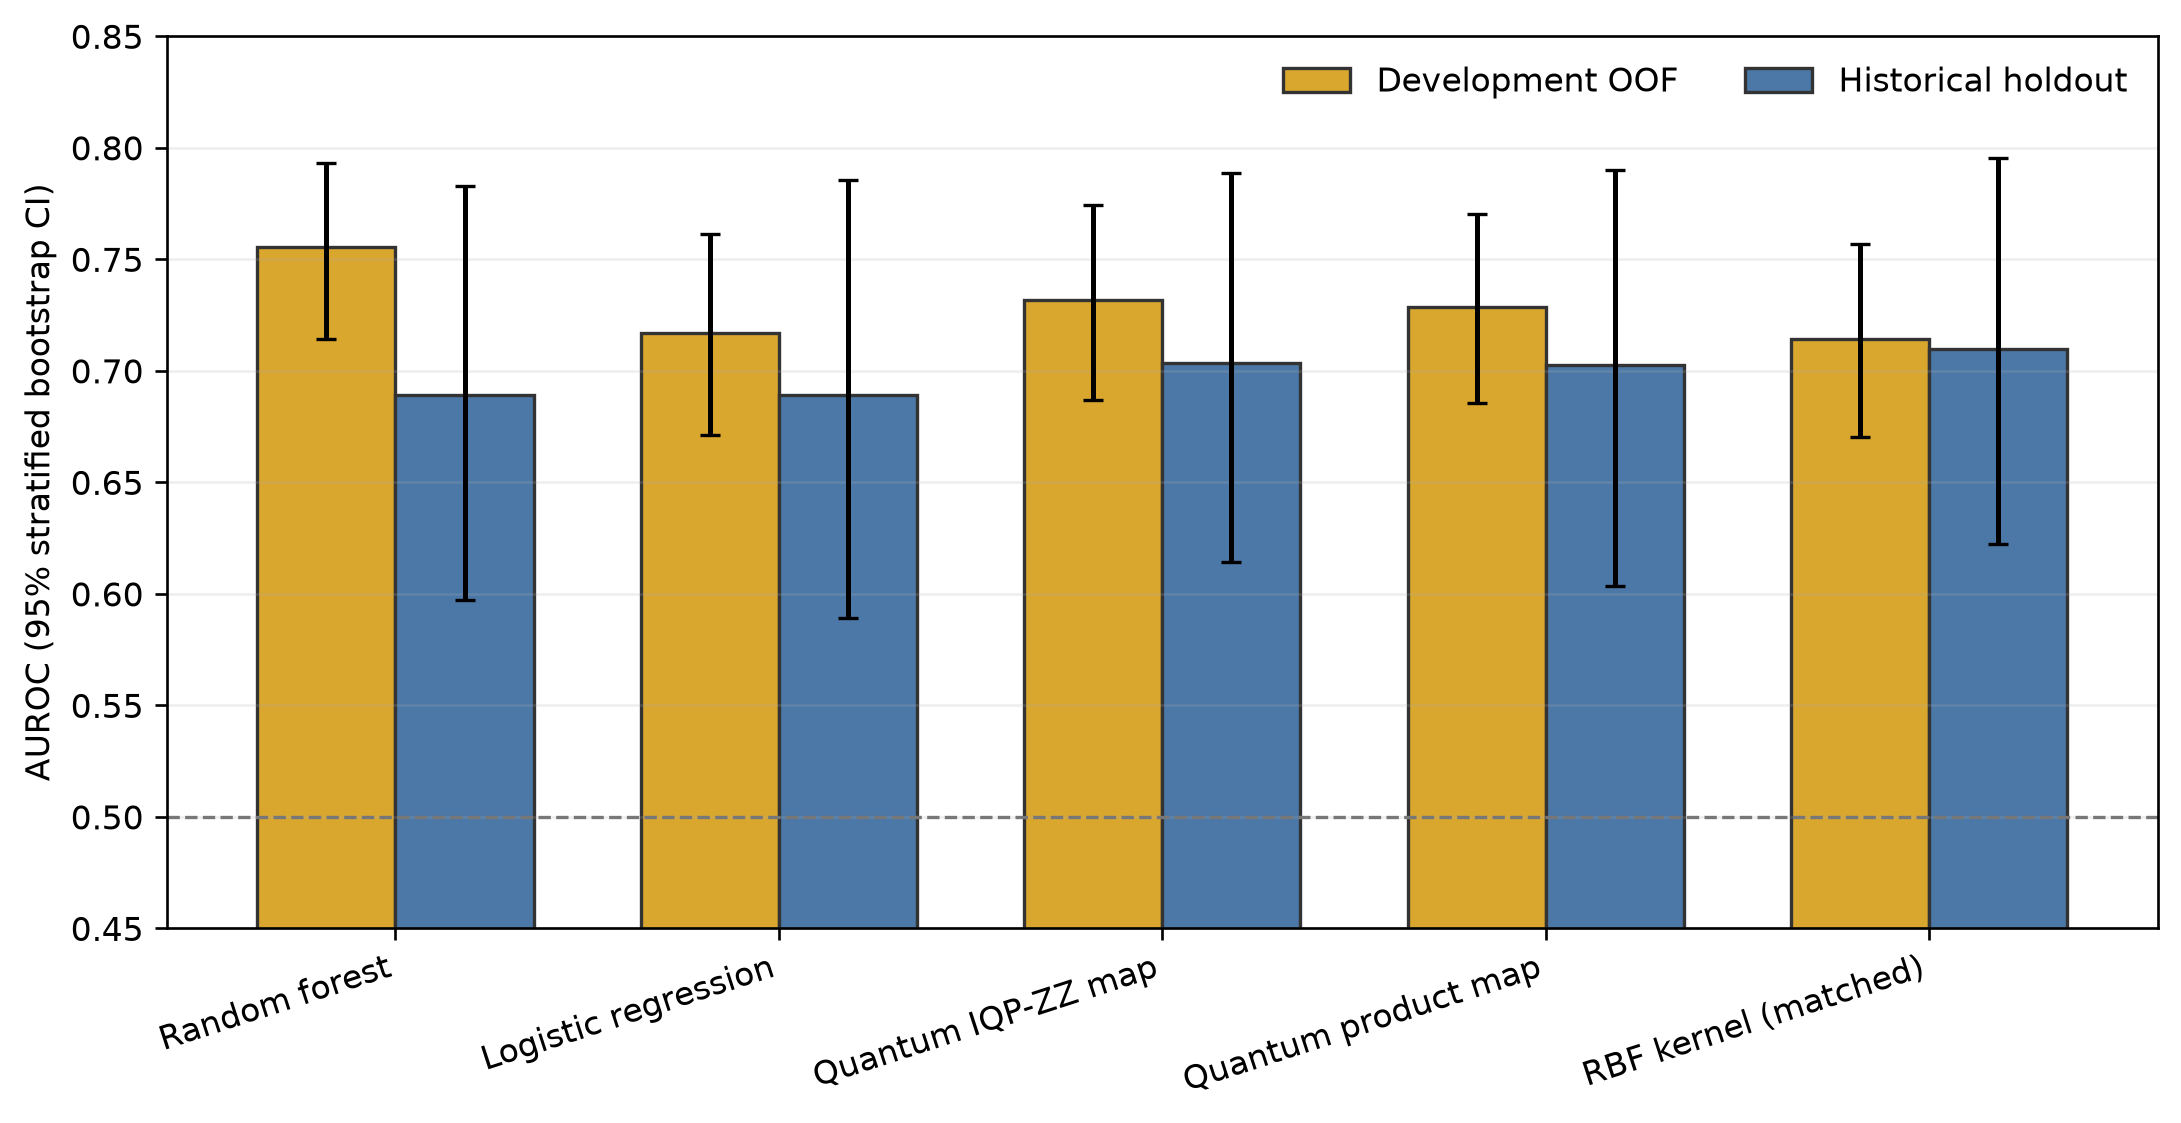

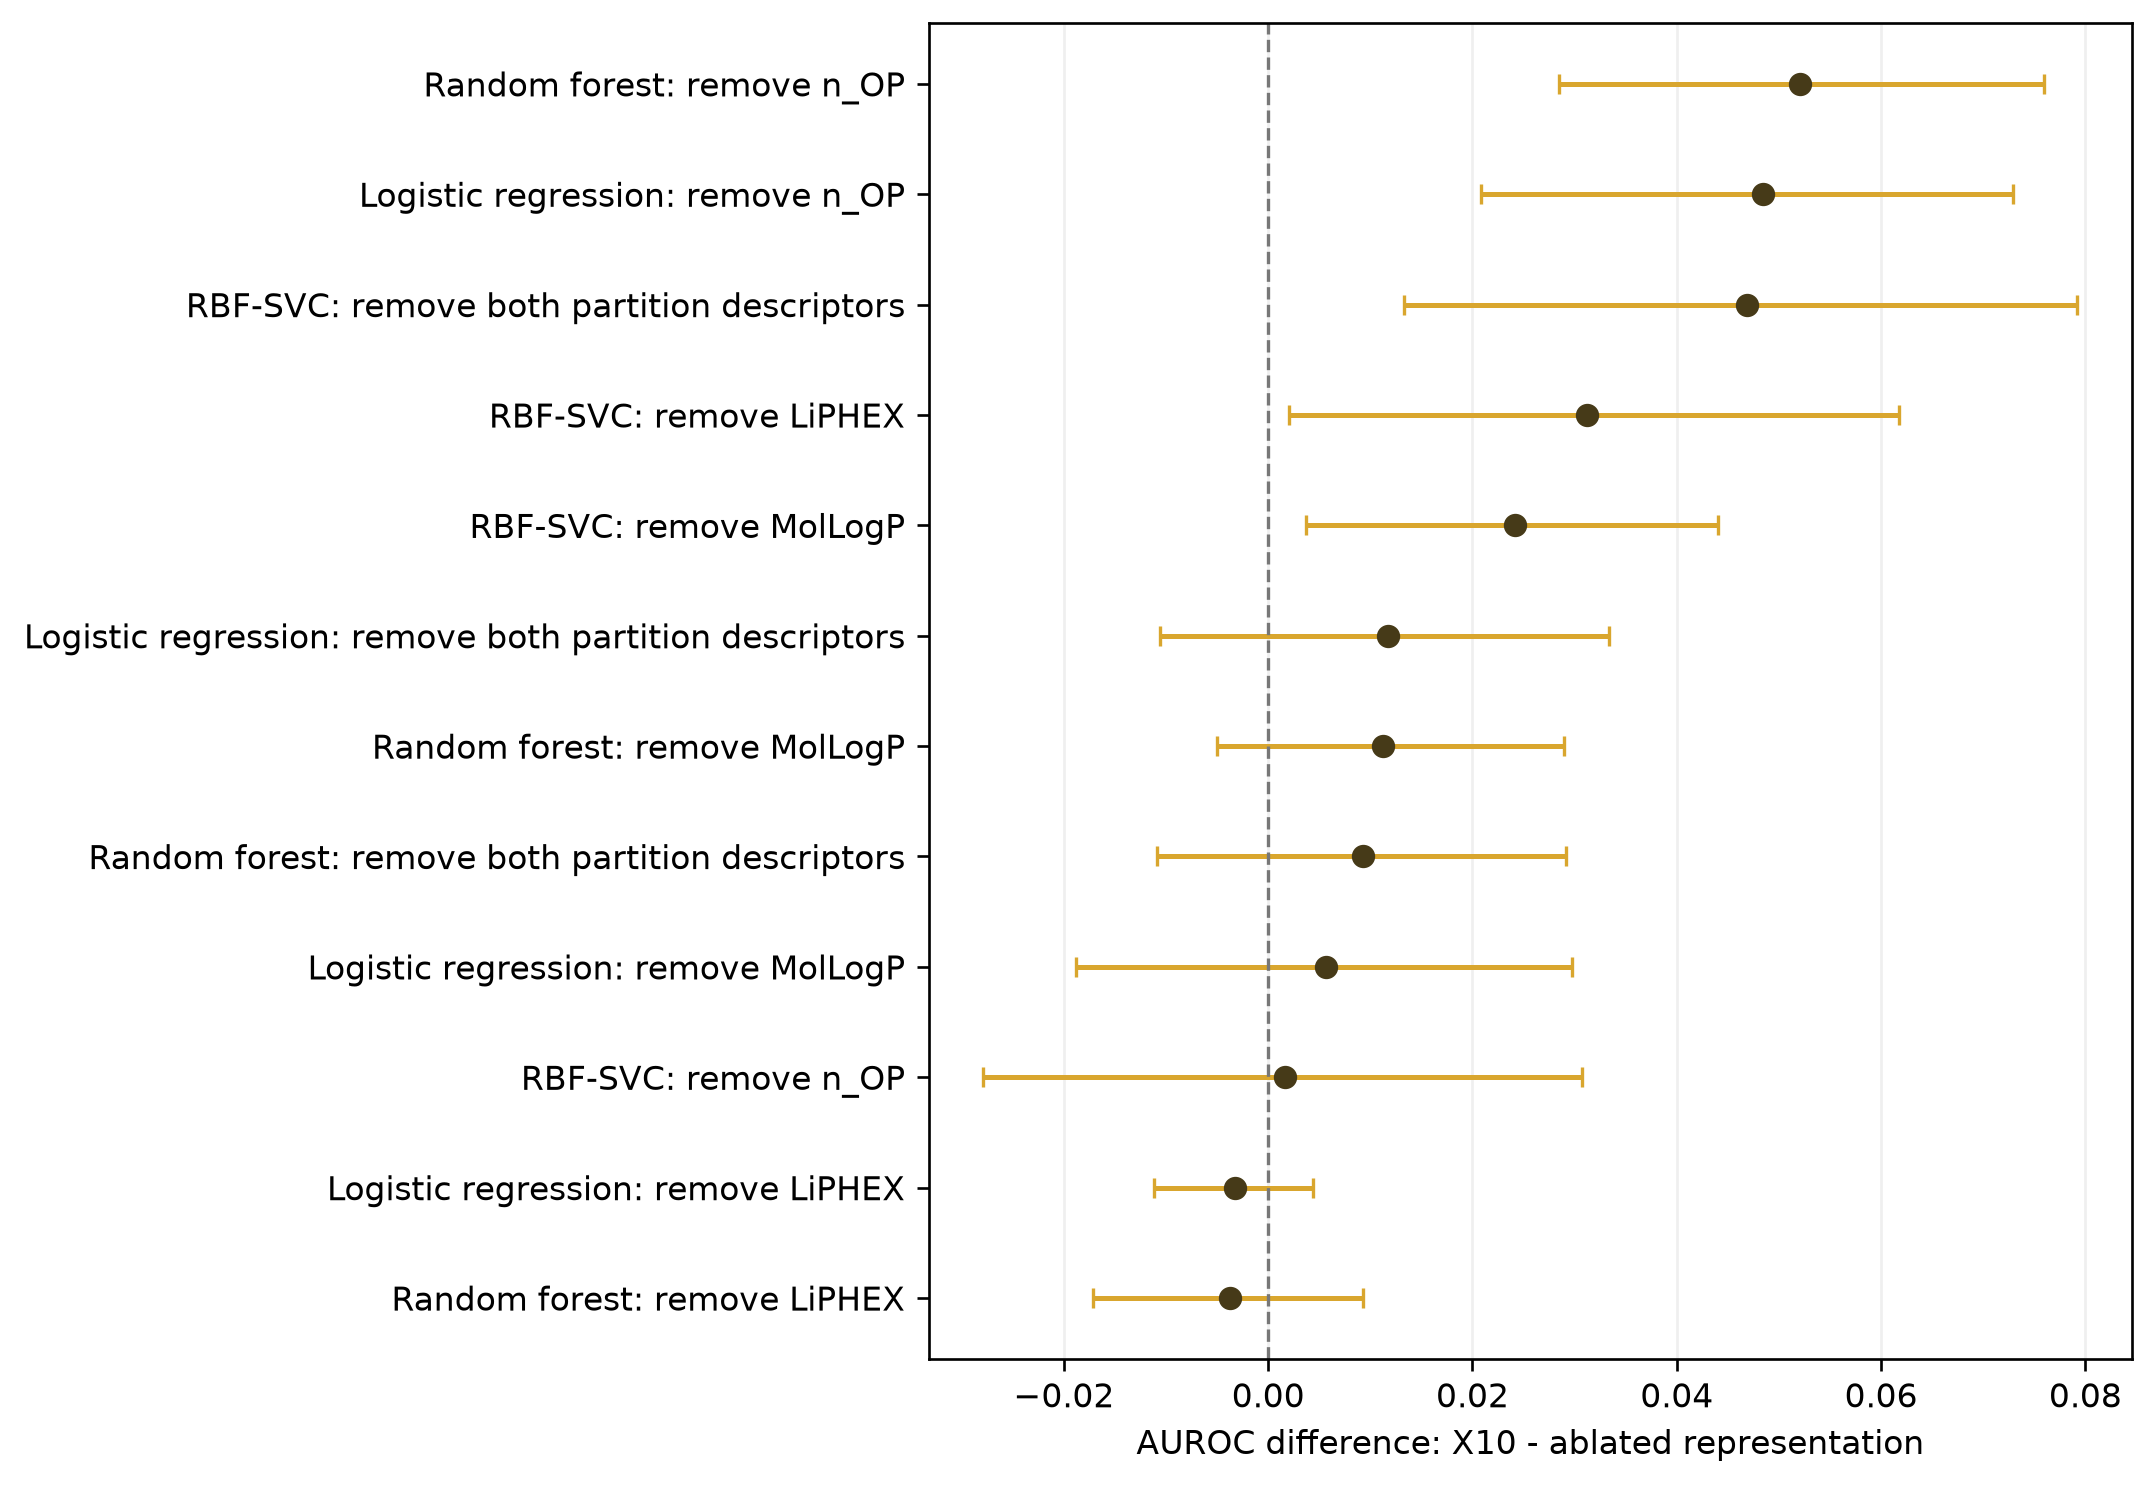

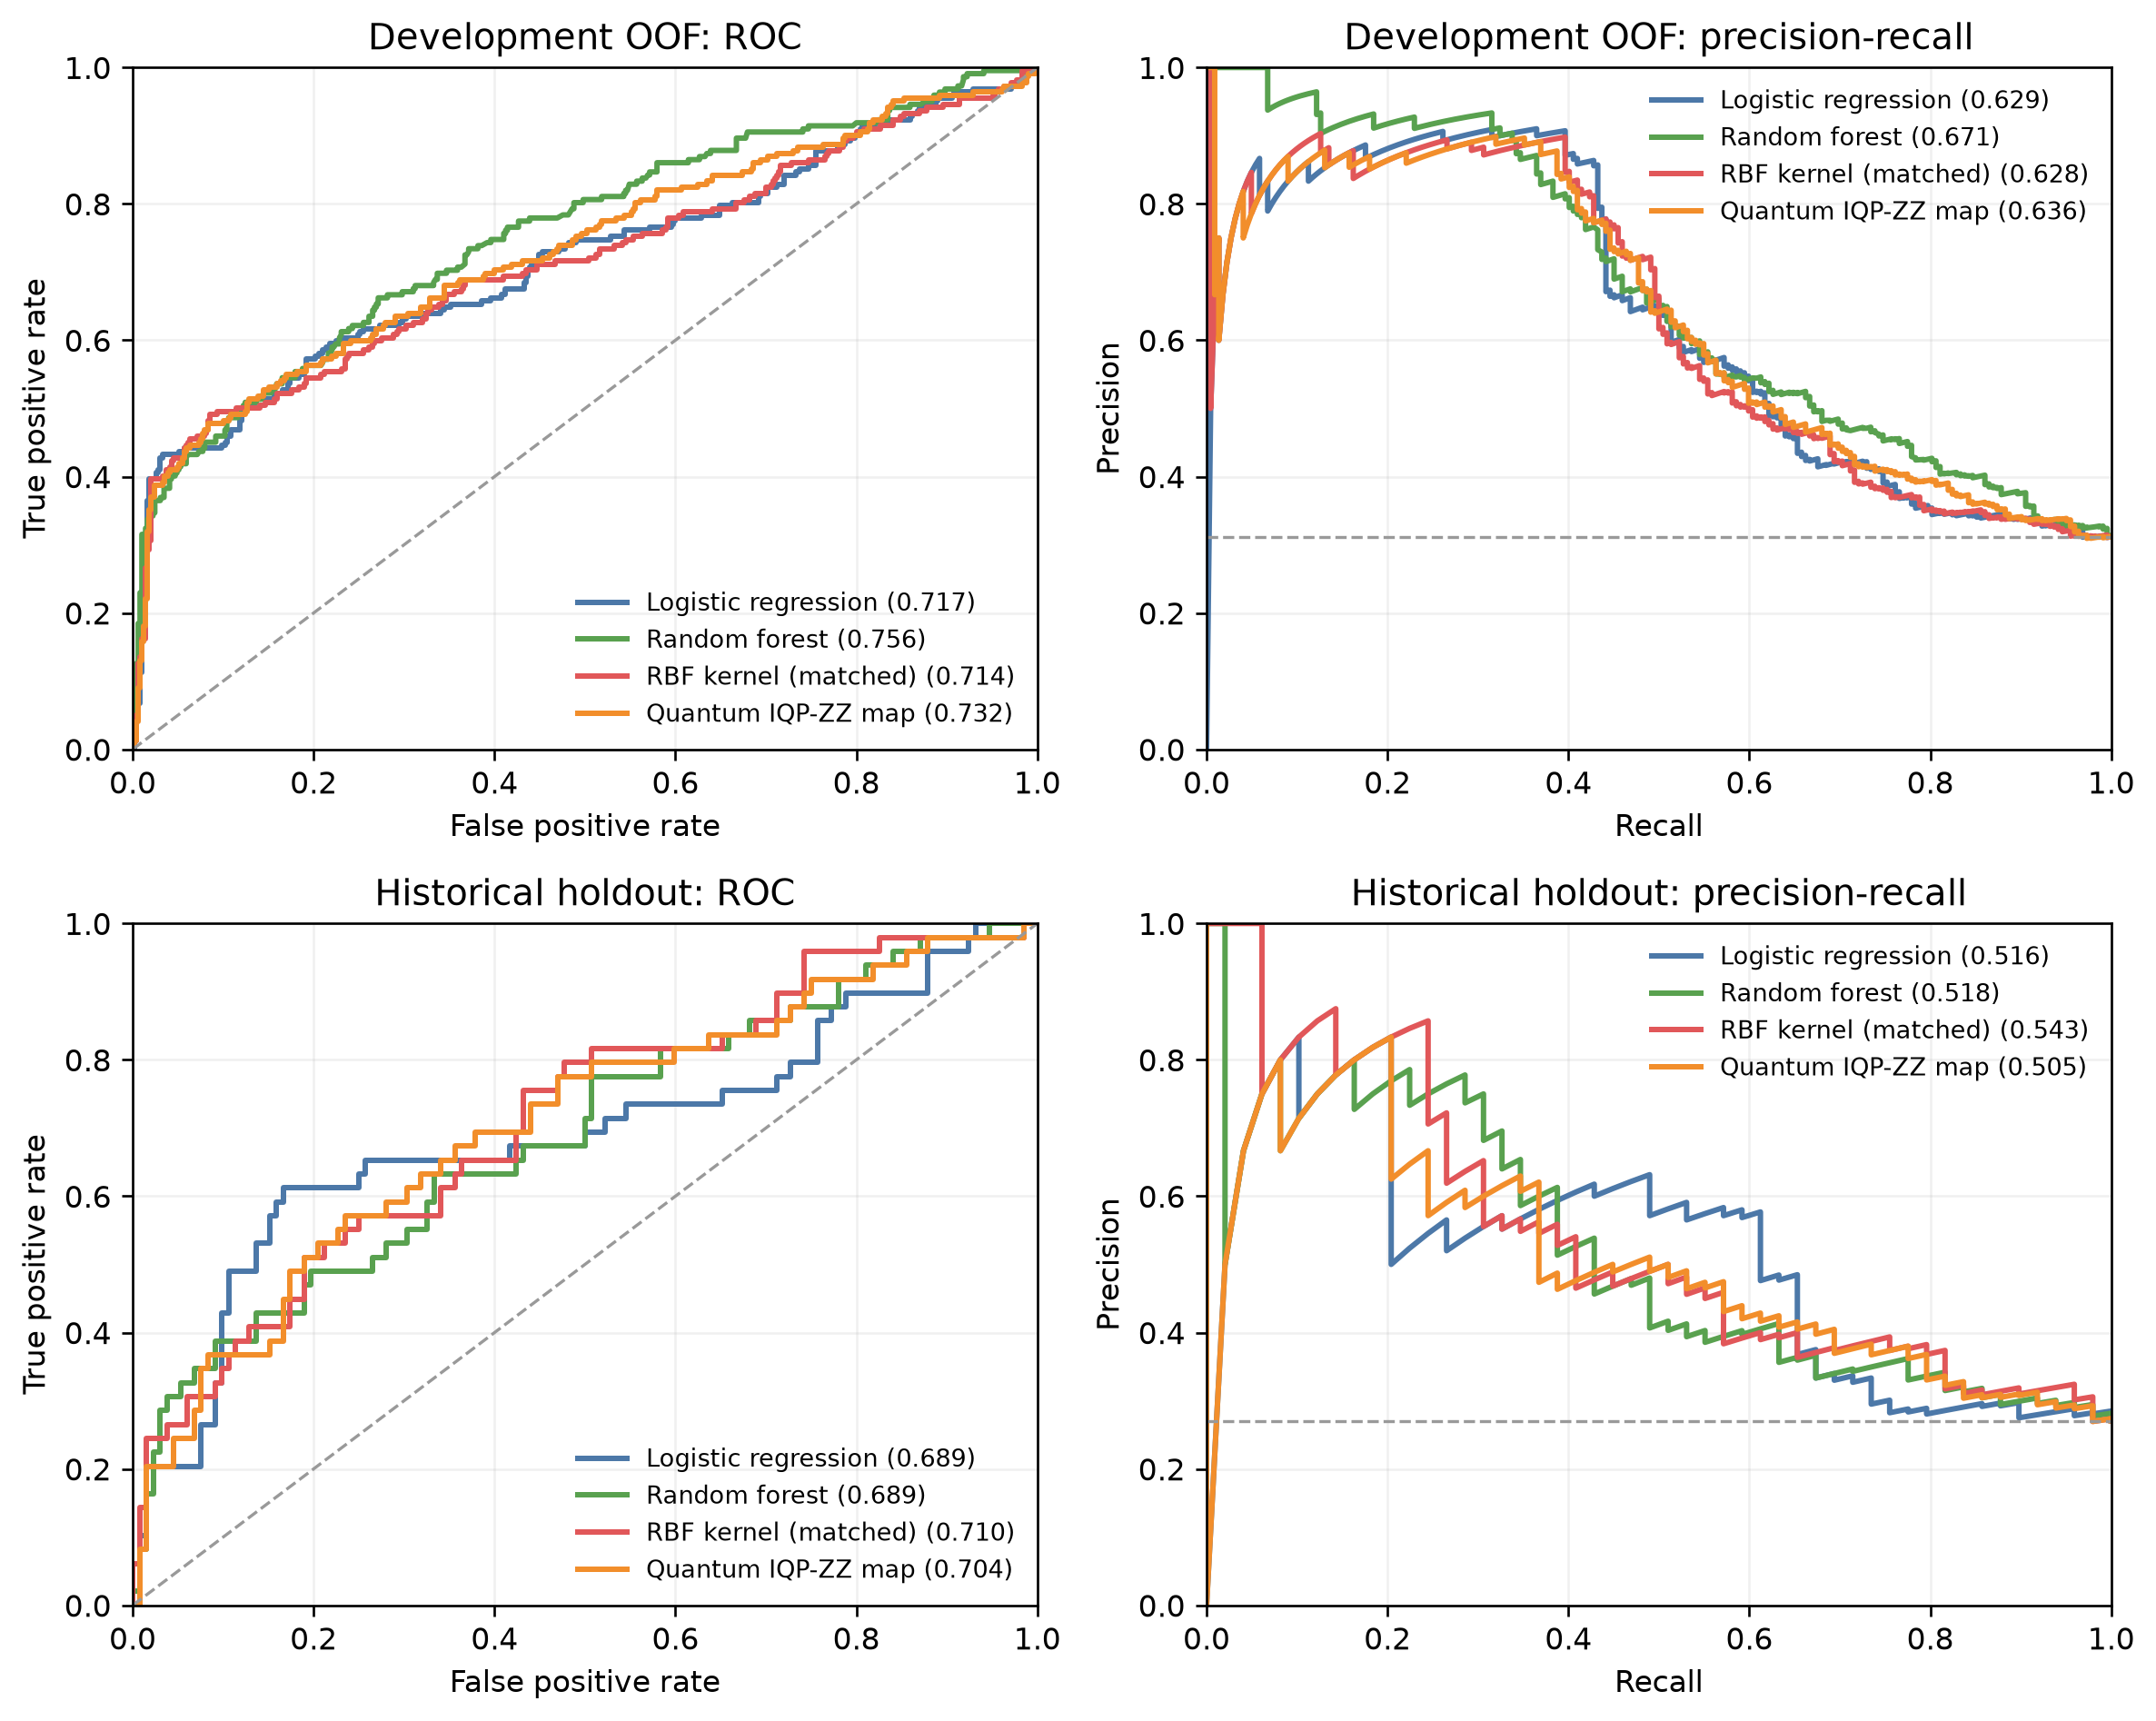

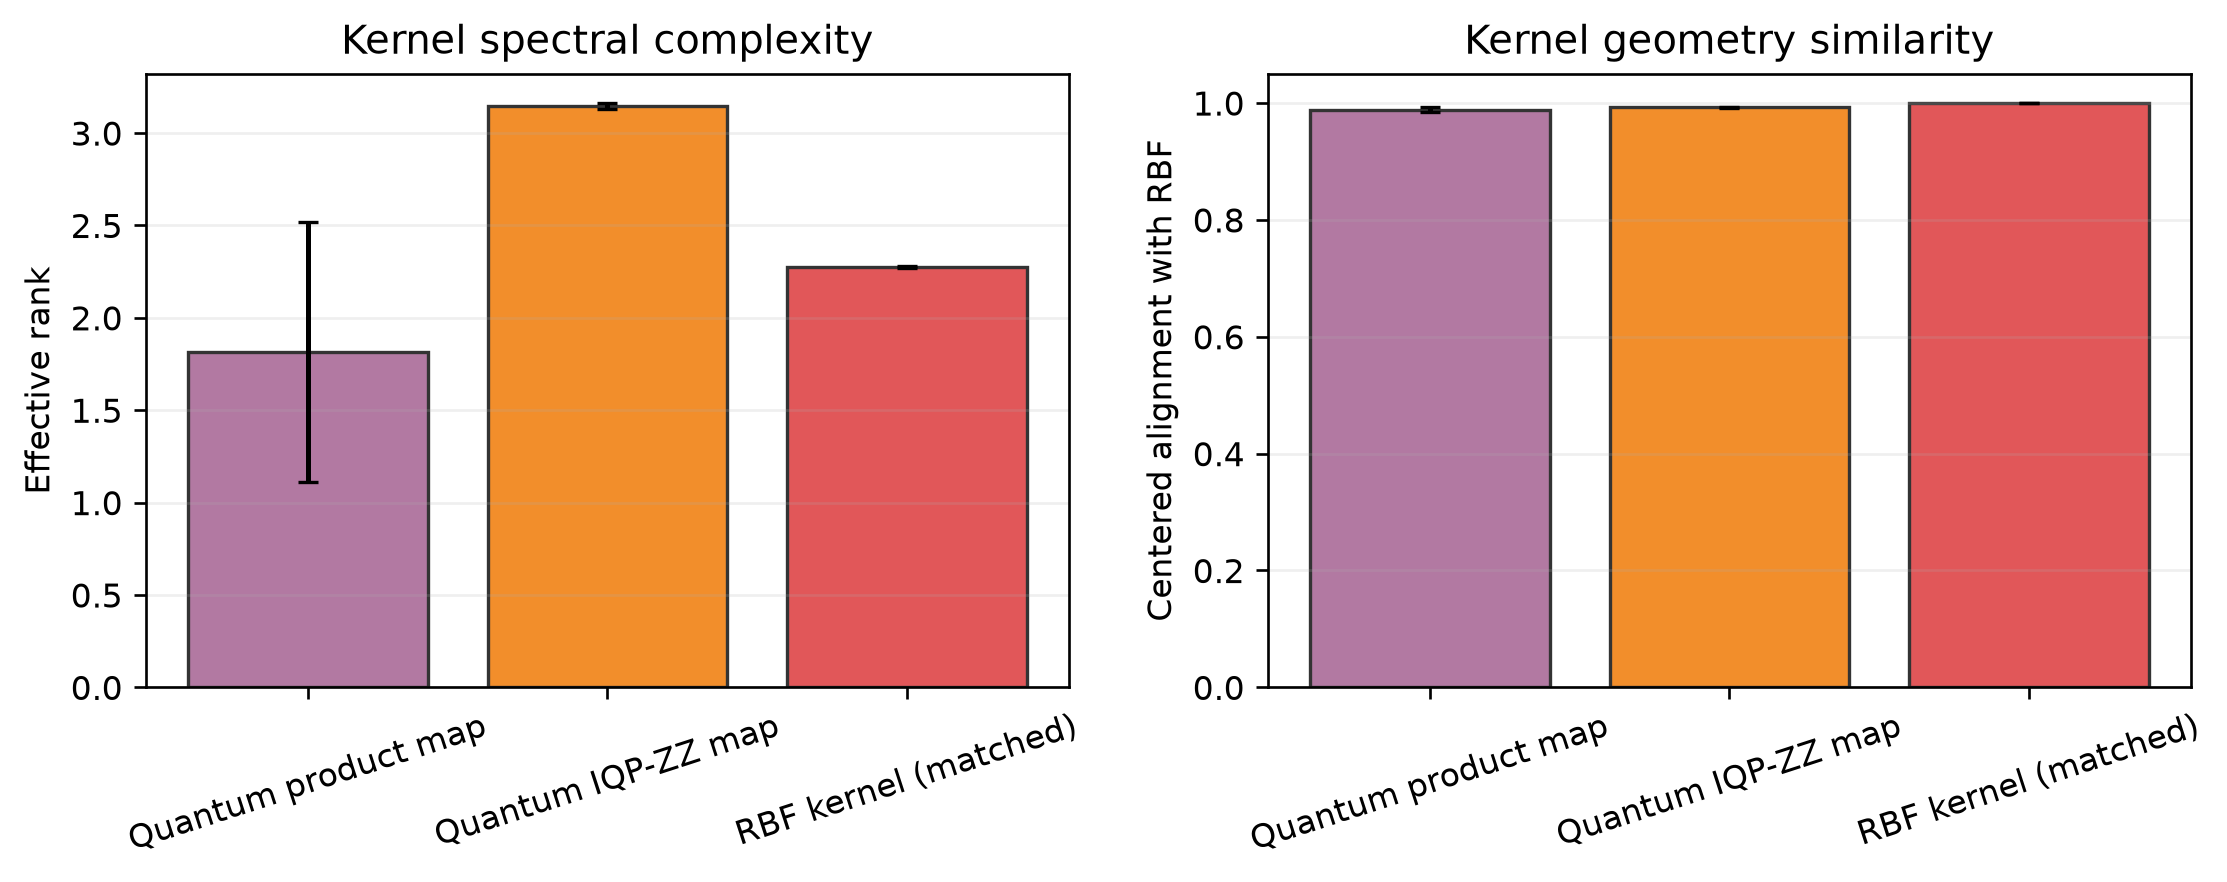

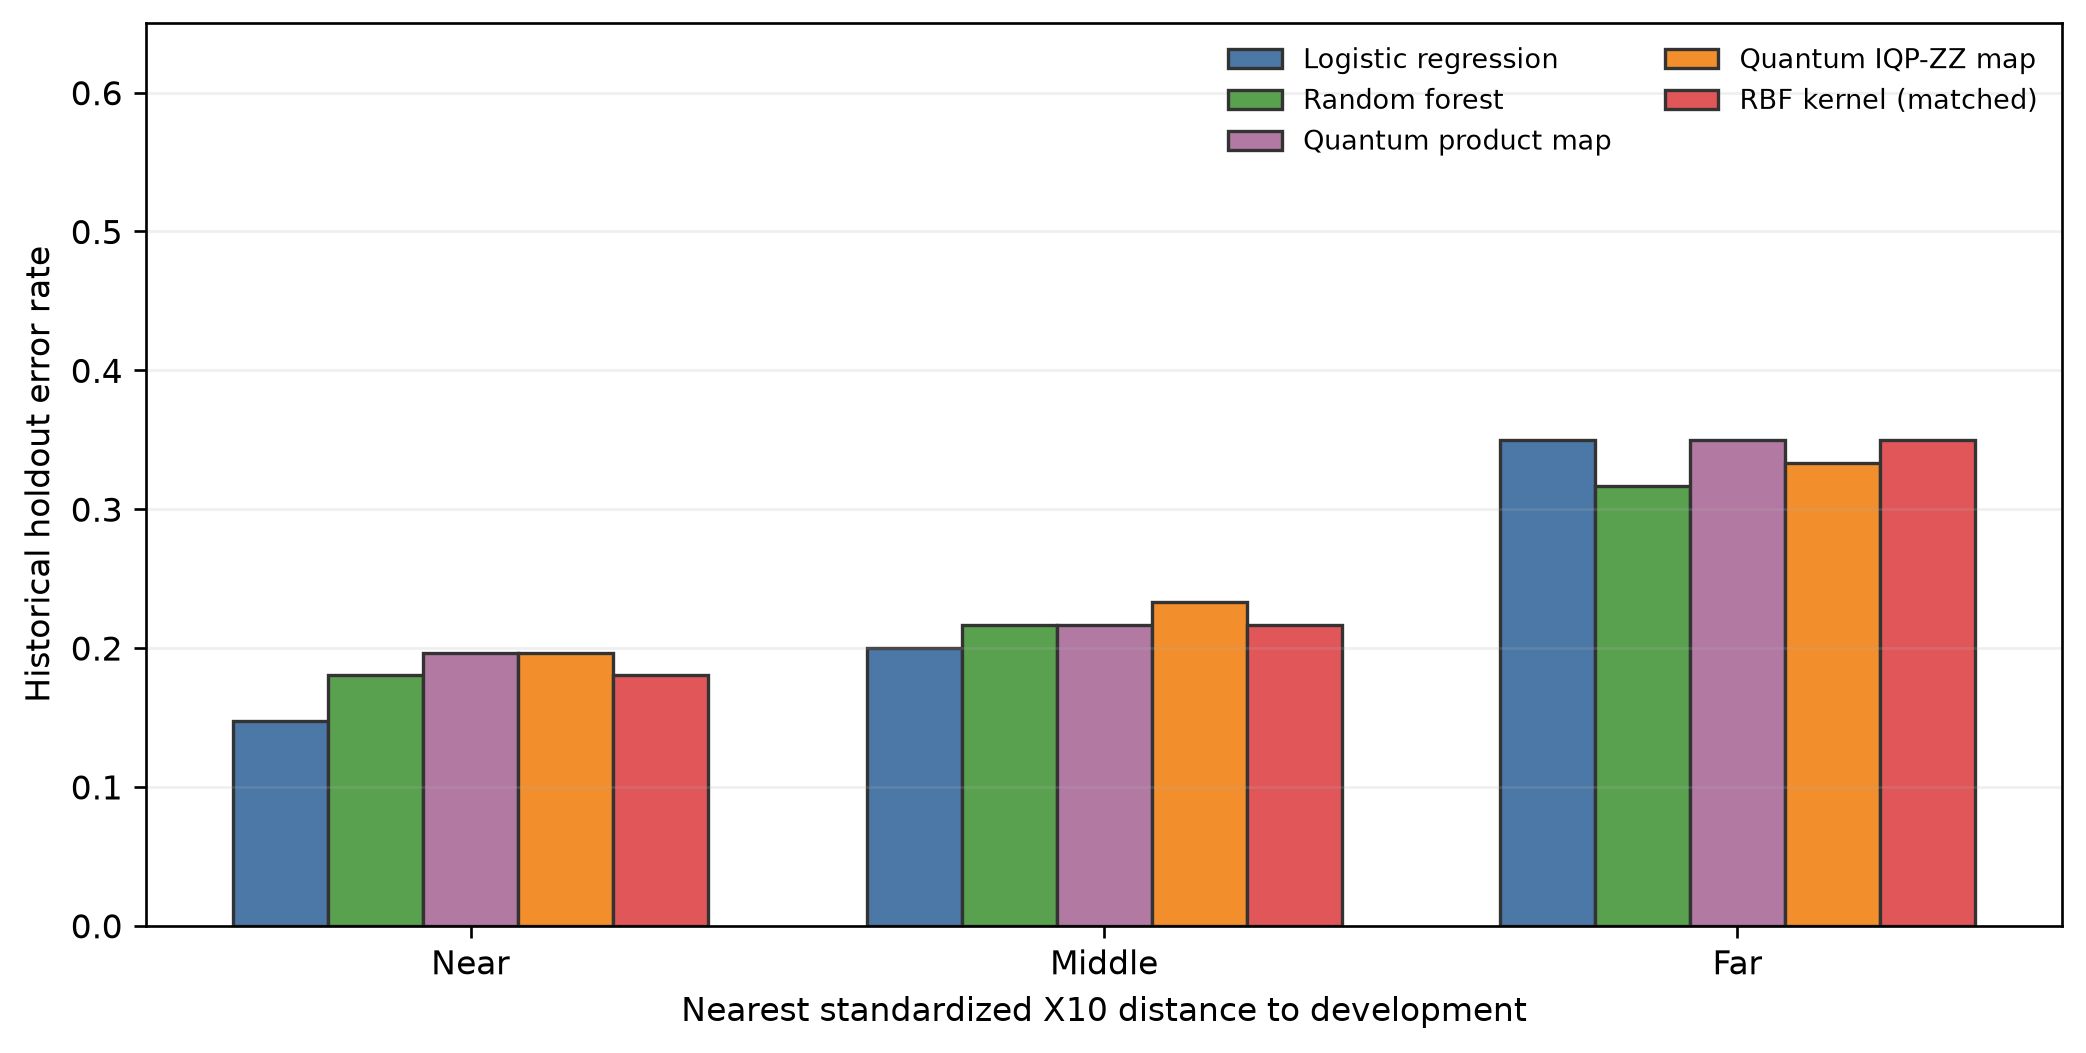

In [11]:
display(Image(filename=str(FINAL_RUN / 'figures' / 'x10_model_overview.png'), width=820))
display(Image(filename=str(FINAL_RUN / 'figures' / 'descriptor_ablation.png'), width=820))
display(Image(filename=str(FINAL_RUN / 'figures' / 'roc_pr_curves.png'), width=820))
display(Image(filename=str(FINAL_RUN / 'figures' / 'kernel_geometry.png'), width=820))
display(Image(filename=str(FINAL_RUN / 'figures' / 'holdout_distance_errors.png'), width=820))

## Fase 5 — Manuscrito IEEE/BIP

El manuscrito enlaza tablas y figuras generadas, diferencia evidencia OOF de holdout histórico y conserva autores anónimos para revisión doble ciego.

In [12]:
paper_command = ['latexmk', '-pdf', '-interaction=nonstopmode', '-halt-on-error', 'main.tex']
print('Comando:', ' '.join(paper_command))
if BUILD_PAPER:
    subprocess.run(paper_command, cwd=ROOT / 'paper', check=True)

paper_pdf = ROOT / 'output' / 'pdf' / 'BeeQ_BIP2026.pdf'
paper_manifest = json.loads((paper_pdf.parent / 'manifest.json').read_text(encoding='utf-8'))
paper_source = (ROOT / 'paper' / 'main.tex').read_text(encoding='utf-8')
paper_status = pd.DataFrame([{
    'archivo': paper_pdf.name,
    'páginas': paper_manifest['page_count'],
    'tamaño_kB': round(paper_pdf.stat().st_size / 1024, 1),
    'doble_ciego': 'Anonymous Authors' in paper_source,
}])
display(paper_status)
print('PDF final:', paper_pdf)

Comando: latexmk -pdf -interaction=nonstopmode -halt-on-error main.tex


,archivo,páginas,tamaño_kB,doble_ciego
0,BeeQ_BIP2026.pdf,6,786.2,True


PDF final: C:\Github_Repos\BeeQ\output\pdf\BeeQ_BIP2026.pdf


### Lectura final

X10 conserva señal predictiva en moléculas estructuralmente separadas. `n_OP` y los dos descriptores de partición aportan información dependiente del modelo. Los kernels cuánticos muestran una diferencia OOF pequeña frente al RBF, pero su alta alineación y la ausencia de mejora en el holdout no respaldan una ventaja cuántica generalizable.